<a href="https://colab.research.google.com/github/MireckaZagorova/Public/blob/main/projekt2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ❤️  Heart Failure Prediction - projekt
**Autor:** ZAG0018, Zagorová Miroslava

**Datum:** do 11.1. 2026

Kombinované studium


# 1. Nahrání dat


In [ ]:
import pandas as pd

df = pd.read_csv("/content/heart.csv")
df


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


***
# 2. Úvod a popis problému
## 2.1. Základní přehled dat

Dataset se zaměřuje na zdravotní údaje jednotlivých pacientů a jejich vztah
k výskytu srdečního onemocnění. Každý řádek v datasetu představuje jednoho
pacienta, u kterého byly zaznamenány základní demografické informace,
naměřené zdravotní hodnoty a výsledky vybraných lékařských vyšetření.


### 2.1.1. Sloupce

* Age	 - Věk pacienta (v letech)
* Sex	- Pohlaví pacienta (0 = žena, 1 = muž)
* ChestPainType - Typ bolesti na hrudi
* RestingBP	- Klidový krevní tlak
* Cholesterol	- Hladina cholesterolu v krvi
* FastingBS	- Zvýšený cukr nalačno (1 = ano, 0 = ne)
* RestingECG	- Výsledek EKG v klidu
* MaxHR	Maximální - dosažená tepová frekvence
* ExerciseAngina	- Bolest na hrudi při fyzické zátěži (ano / ne)
* Oldpeak	- Pokles ST úseku při zátěži
* ST_Slope	- Tvar ST úseku na EKG
* HeartDisease	- Výskyt srdečního onemocnění (cílová proměnná)


### 2.1.2. Vysvětlení hodnot

#### ChestPainType - Typ bolesti na hrudi
* TA - Typická angína
* ATA - Atypická angína
* NAP - bolest nesouvisející s angínou
* ASY - bez bolesti

#### RestingECG (EKG v klidu)
*   Normal - normální výsledek
*   ST - abnormalita ST úseku
*   LVH - hypertrofie levé komory

#### ST_Slope (tvar ST úseku)
* Up
* Flat
* Down

#### Pohlaví
* 0 = žena
* 1 = muž

#### FastingBS (cukr nalačno)
* 0 = normální hodnota
* 1 = zvýšený cukr

#### HeartDisease
* 0 = bez srdečního onemocnění
* 1 = přítomno srdeční onemocnění

<br>

***

<br>

##2.2. Typy proměnných


### Dataset obsahuje:
* Číselné hodnoty - Věk, RestingBP, Cholesterol, MaxHR, Oldpeak
* Kategoriální hodnoty - ChestPainType, RestingECG, ST_Slope,
* Binární hodnoty - Pohlaví, FastingBS, ExerciseAngina, HeartDisease
<br>

***

<br>

##2.3. Jaký je cíl projektu

Cílem projektu je vytvořit klasifikační model, který na základě dostupných
zdravotních údajů pacienta dokáže předpovědět, zda u daného pacienta
dochází k výskytu srdečního onemocnění.

Model využívá informace o věku, pohlaví, naměřených zdravotních hodnotách
a výsledcích lékařských vyšetření. Cílem je porovnat různé klasifikační
algoritmy a zhodnotit jejich úspěšnost při predikci srdečního onemocnění.

<br>

***

<br>

##2.4. Rozdělení cílové proměnné

Cílovou proměnnou v datasetu je sloupec HeartDisease, který nabývá hodnot 0 a 1.
Hodnota 0 označuje pacienty bez srdečního onemocnění, zatímco hodnota 1
označuje pacienty se srdečním onemocněním.

Rozdělení cílové proměnné ukazuje, jaký je poměr zdravých a nemocných pacientů
v datasetu. Tento poměr je důležitý pro volbu metrik hodnocení modelu a pro
správné použití křížové validace.

<br>

***

<br>


#3. Průzkum dat - EDA
##3.1. Základní přehled dat

### Náhled na data

In [ ]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


### Rozměr datasetu

In [ ]:
df.shape

(918, 12)

### Informace o sloupcích

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


### Základní statistiky číselných dat

In [ ]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


##3.2. Nulové - chybějící hodnoty
Dataset neobsahuje nulové hodnoty

In [ ]:
df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


##3.3. Rozdělení cílové proměnné
V této části je analyzováno rozdělení cílové proměnné HeartDisease,
která určuje výskyt srdečního onemocnění u pacientů.

### Počty hodnot


In [ ]:
df['HeartDisease'].value_counts()


,count
HeartDisease,
1,508
0,410


### Počet hodnot - v procentech


In [ ]:
df['HeartDisease'].value_counts(normalize=True) * 100


,proportion
HeartDisease,
1,55.337691
0,44.662309


### Sloupcový graf

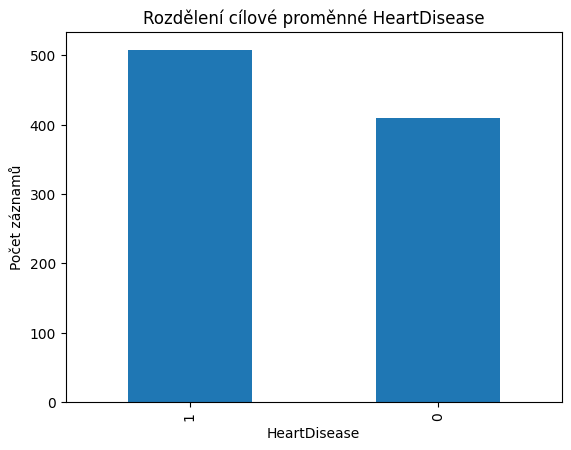

In [ ]:
import matplotlib.pyplot as plt

df['HeartDisease'].value_counts().plot(kind='bar')
plt.xlabel('HeartDisease')
plt.ylabel('Počet záznamů')
plt.title('Rozdělení cílové proměnné HeartDisease')
plt.show()


Z rozdělení cílové proměnné je patrné, že dataset obsahuje pacienty
se srdečním onemocněním i bez něj. Třídy nejsou výrazně nevyvážené,
což je vhodné pro použití klasifikačních algoritmů a křížové validace.



#4. Příprava dat
##4.1. Popis jednotlivých sloupců

V této kapitole je uveden stručný popis jednotlivých sloupců datasetu a jejich
zařazení podle typu proměnné. Dataset obsahuje kombinaci číselných,
kategoriálních a binárních proměnných, které popisují zdravotní stav pacienta.

Číselné proměnné:
- Age – věk pacienta v letech
- RestingBP – klidový krevní tlak
- Cholesterol – hladina cholesterolu v krvi
- MaxHR – maximální dosažená tepová frekvence
- Oldpeak – pokles ST úseku při fyzické zátěži

Binární proměnné:
- Sex – pohlaví pacienta (0 = žena, 1 = muž)
- FastingBS – zvýšený cukr nalačno (0 = ne, 1 = ano)
- ExerciseAngina – výskyt bolesti na hrudi při fyzické zátěži (ano / ne)

Kategoriální proměnné:
- ChestPainType – typ bolesti na hrudi
- RestingECG – výsledek EKG v klidu
- ST_Slope – tvar ST úseku na EKG

Cílová proměnná:
- HeartDisease – výskyt srdečního onemocnění (0 = bez onemocnění, 1 = přítomno)

<br>

***

<br>


##4.2. Jaké úpravy jsou potřebné a proč

Cílem přípravy dat je převést původní dataset do podoby vhodné pro použití
klasifikačních algoritmů. Jednotlivé úpravy budou zvoleny s ohledem na typ
proměnných a jejich význam.

Číselné proměnné budou ponechány v původní podobě, případně následně škálovány,
aby se nacházely ve stejném rozsahu hodnot. Škálování pomáhá zejména
algoritmům citlivým na velikost hodnot, jako je například metoda
k-nejbližších sousedů.

Kategoriální proměnné nemohou být přímo použity v klasifikačních modelech,
proto budou převedeny na číselnou reprezentaci pomocí metody one-hot encoding.
Tato metoda umožňuje zachovat informaci o jednotlivých kategoriích bez
zavedení falešného pořadí mezi nimi.

Binární proměnné budou ponechány beze změny, jelikož již mají vhodnou číselnou
reprezentaci.

Cílová proměnná nebude nijak upravována a bude použita pouze jako výstup
modelu.

<br>

***

<br>

##4.3. Kódování kategoriálních proměnných


### Rozdělení na vstupy a cílovou proměnnou

In [ ]:
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']


### Seznam kategoriálních sloupců

In [ ]:
categorical_features = ['ChestPainType', 'RestingECG', 'ST_Slope']


### Převod binárních hodnot

In [ ]:
X['Sex'] = X['Sex'].map({'M': 1, 'F': 0})
X['ExerciseAngina'] = X['ExerciseAngina'].map({'Y': 1, 'N': 0})

###One-hot encoding

In [ ]:
X = pd.get_dummies(
    X,
    columns=['ChestPainType', 'RestingECG', 'ST_Slope'],
    drop_first=False
)

### Kontrola

In [ ]:
X.dtypes


,0
Age,int64
Sex,int64
RestingBP,int64
Cholesterol,int64
FastingBS,int64
MaxHR,int64
ExerciseAngina,int64
Oldpeak,float64
ChestPainType_ASY,bool
ChestPainType_ATA,bool


##4.4. Škálování číslených proměnných

In [ ]:
numeric_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()


In [ ]:
X[numeric_features] = scaler.fit_transform(X[numeric_features])


Číselné proměnné byly škálovány pomocí metody Min-Max scaling, která převádí
hodnoty do intervalu od 0 do 1. Škálování bylo použito z důvodu rozdílných
rozsahů jednotlivých číselných proměnných a je důležité zejména pro
algoritmy citlivé na velikost hodnot, jako je metoda k-nejbližších sousedů.


In [ ]:
X[numeric_features].describe()


,Age,RestingBP,Cholesterol,MaxHR,Oldpeak
count,918.000000,918.000000,918.000000,918.000000,918.000000
mean,0.520630,0.661983,0.329684,0.540911,0.396291
std,0.192502,0.092571,0.181400,0.179298,0.121201
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.387755,0.600000,0.287313,0.422535,0.295455
50%,0.530612,0.650000,0.369818,0.549296,0.363636
75%,0.653061,0.700000,0.442786,0.676056,0.465909
max,1.000000,1.000000,1.000000,1.000000,1.000000


Po aplikaci Min-Max škálování se hodnoty všech číselných proměnných
nacházejí v intervalu od 0 do 1, což potvrzuje správné provedení škálování.


#5. Rozdělení dat na trénovací a testovací
##5.1. Jak jsou data rozdělena
Dataset byl rozdělen na trénovací a testovací část. Trénovací data slouží
k učení klasifikačních modelů, zatímco testovací data budou použita pro
nezávislé vyhodnocení jejich výkonu.

Data jsou rozdělena v poměru 80 % pro trénovací sadu a 20 % pro testovací
sadu. Při rozdělení byla použita stratifikace podle cílové proměnné,
aby byl zachován stejný poměr tříd v obou částech datasetu.


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


##5.2. Proč je to důležité
Rozdělení dat na trénovací a testovací část je důležité pro objektivní
vyhodnocení výkonu modelu. Pokud by byl model hodnocen na stejných datech,
na kterých byl natrénován, mohlo by dojít k nadhodnocení jeho přesnosti.

Použití samostatné testovací množiny umožňuje ověřit, jak dobře je model
schopen generalizovat na nová, dosud neviděná data. Stratifikované rozdělení
navíc zajišťuje, že poměr tříd zůstává zachován, což je důležité zejména
u klasifikačních úloh.


#6. Metody hodnocení modelu
##6.1. Jaké metriky byly použity
Pro hodnocení výkonu klasifikačních modelů bylo použito několik běžně
používaných metrik. Tyto metriky umožňují posoudit úspěšnost modelu
z různých pohledů.

Použité metriky:
- Accuracy – podíl správně klasifikovaných záznamů
- Precision – podíl správně predikovaných pozitivních případů
- Recall – schopnost modelu správně zachytit pozitivní případy
- F1-score – harmonický průměr metrik Precision a Recall

<br>

***

<br>

##6.2. Která metrika je důležitější a proč

Za nejdůležitější metriku byla zvolena hodnota F1-score. Tato metrika
kombinuje precision a recall a poskytuje vyvážený pohled na výkon modelu
v případech, kdy není žádoucí upřednostňovat pouze jednu z těchto metrik.

Vzhledem k tomu, že cílem projektu je správně identifikovat pacienty se
srdečním onemocněním, je důležité minimalizovat jak falešně pozitivní,
tak falešně negativní predikce. F1-score je proto vhodnější než samotná
accuracy, která může být zavádějící při nerovnoměrném rozdělení tříd.


#7. Použité klasifikační algoritmy
##7.1. Rozhodovací strom
Rozhodovací strom je jednoduchý a dobře interpretovatelný klasifikační
algoritmus, který rozděluje data na základě hodnot jednotlivých proměnných.
Model vytváří stromovou strukturu rozhodnutí, která vede k výsledné
klasifikaci.

Výhodou rozhodovacího stromu je jeho snadná interpretace a schopnost
pracovat s různými typy proměnných. Nevýhodou může být náchylnost
k přeučení při příliš hlubokém stromu.

### Import

In [ ]:
from sklearn.tree import DecisionTreeClassifier


### Vytvoření a natrénování modelu

In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

### Predikce

In [ ]:
y_pred_dt = dt_model.predict(X_test)


### Výpočet metrik

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)

dt_accuracy, dt_precision, dt_recall, dt_f1


(0.7771739130434783, 0.801980198019802, 0.7941176470588235, 0.7980295566502463)

Rozhodovací strom dosáhl na testovacích datech hodnoty accuracy přibližně 77 %.
Hodnota precision ukazuje, že model je poměrně úspěšný v přesné identifikaci
pacientů se srdečním onemocněním, zatímco hodnota recall naznačuje schopnost
zachytit většinu skutečně pozitivních případů.

Hodnota F1-score, která kombinuje precision a recall, dosahuje přibližně 0,80,
což představuje vyvážený výkon modelu bez ladění hyperparametrů.


##7.2. Náhodný les
Náhodný les je ensemble klasifikační algoritmus, který kombinuje více
rozhodovacích stromů do jednoho modelu. Každý strom je trénován na náhodném
výběru dat a proměnných, čímž se snižuje riziko přeučení a zvyšuje se
stabilita výsledků.

Očekává se, že náhodný les dosáhne lepších výsledků než jednotlivý
rozhodovací strom, zejména z hlediska generalizace na testovací data.

###Import

In [ ]:
from sklearn.ensemble import RandomForestClassifier


### Vytvoření a natrénování modelu

In [ ]:
rf_model = RandomForestClassifier(
    random_state=42,
    n_estimators=100
)

rf_model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

### Predikce

In [ ]:
y_pred_rf = rf_model.predict(X_test)


### Vyhodnocení modelu

In [ ]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

rf_accuracy, rf_precision, rf_recall, rf_f1


(0.8804347826086957,
 0.8846153846153846,
 0.9019607843137255,
 0.8932038834951457)

Náhodný les dosáhl výrazně lepších výsledků než základní rozhodovací strom.
Hodnota accuracy se pohybuje okolo 88 %, přičemž model dosahuje vysokých
hodnot precision i recall. Zvláště hodnota recall naznačuje, že model je
schopen správně identifikovat většinu pacientů se srdečním onemocněním.

Hodnota F1-score potvrzuje vyvážený výkon modelu a jeho lepší schopnost
generalizace na testovací data ve srovnání s jednotlivým rozhodovacím stromem.


##7.3. K-nejbližších sousedů

Algoritmus k-nejbližších sousedů (kNN) patří mezi jednoduché klasifikační
metody založené na podobnosti dat. Klasifikace nového záznamu je určena
na základě třídy jeho k nejbližších sousedů v prostoru vstupních proměnných.

Výhodou algoritmu je jeho jednoduchost a absence fáze učení, nevýhodou
naopak citlivost na volbu parametru k a na měřítko jednotlivých proměnných.


### Import

In [ ]:
from sklearn.neighbors import KNeighborsClassifier


### Vytvoření a natrénování modelu
Zvolíme rozumnou základní hodnotu k = 5

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)


KNeighborsClassifier()

### Predikce

In [ ]:
y_pred_knn = knn_model.predict(X_test)


### Vyhodnocení modelu

In [ ]:
knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn)
knn_recall = recall_score(y_test, y_pred_knn)
knn_f1 = f1_score(y_test, y_pred_knn)

knn_accuracy, knn_precision, knn_recall, knn_f1


(0.8695652173913043,
 0.8679245283018868,
 0.9019607843137255,
 0.8846153846153846)

Algoritmus k-nejbližších sousedů dosáhl dobrých výsledků s hodnotou accuracy
okolo 87 %. Model vykazuje vysokou hodnotu recall, což naznačuje jeho schopnost
správně identifikovat většinu pacientů se srdečním onemocněním.

Ve srovnání s náhodným lesem dosahuje kNN mírně nižších hodnot metrik, což může
souviset s citlivostí algoritmu na volbu parametru k a strukturu dat.


#8. Křižová validace
##8.1. Jaký typ křížové validace byl použit

Pro vyhodnocení klasifikačních algoritmů byla použita stratifikovaná
křížová validace (Stratified k-Fold). Tento přístup zajišťuje, že v každém
rozdělení zůstává zachován poměr tříd cílové proměnné.

V projektu byla použita 5-násobná křížová validace, která představuje
rozumný kompromis mezi výpočetní náročností a stabilitou výsledků.


<br>

***

<br>

##8.2. Křížová validace jednotlivých modelů

### Importy


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


### Rozhodovací strom - křížová validace

In [ ]:
dt_cv_scores = cross_val_score(
    dt_model,
    X,
    y,
    cv=cv,
    scoring='f1'
)

dt_cv_scores, dt_cv_scores.mean()


(array([0.83937824, 0.77894737, 0.78606965, 0.75376884, 0.77511962]),
 np.float64(0.7866567439900601))

Výsledky křížové validace potvrzují rozdíly ve výkonu jednotlivých
klasifikačních algoritmů. Náhodný les dosahuje nejvyšší průměrné hodnoty
F1-score napříč jednotlivými foldy, což naznačuje jeho stabilitu a dobrou
schopnost generalizace.

Rozhodovací strom vykazuje nižší a méně stabilní výkon, zatímco model
k-nejbližších sousedů dosahuje vyvážených výsledků, avšak s mírně nižším
průměrným výkonem než náhodný les.


#9. Ladění hyperparametrů
##9.1. Jaké parametry byly laděny

V této kapitole bylo provedeno ladění hyperparametrů vybraných
klasifikačních algoritmů s cílem zlepšit jejich výkon. Hyperparametry
ovlivňují chování modelu a jeho schopnost generalizace na nová data.

U rozhodovacího stromu byly laděny parametry omezující složitost modelu,
zejména maximální hloubka stromu. U algoritmu k-nejbližších sousedů byl
laděn počet sousedů k. Největší pozornost byla věnována algoritmu
náhodného lesa, u kterého bylo laděno více hyperparametrů, včetně počtu
stromů a maximální hloubky jednotlivých stromů.

<br>

***

<br>


##9.2. Kolik experimentů bylo provedeno

Ladění hyperparametrů bylo provedeno formou několika experimentů s různým
nastavením vybraných parametrů jednotlivých klasifikačních algoritmů.
Cílem těchto experimentů bylo porovnat vliv změny hyperparametrů na výkon
modelů, zejména z hlediska hodnoty F1-score.

Celkem bylo provedeno více než 15 experimentů napříč všemi použitými
algoritmy. U rozhodovacího stromu a algoritmu k-nejbližších sousedů byla
vyzkoušena alespoň dvě různá nastavení hyperparametrů. Největší počet
experimentů byl proveden u algoritmu náhodného lesa, který nabízí více
možností ladění a vykazuje nejlepší základní výsledky.

Výsledky jednotlivých experimentů byly následně porovnány a shrnuty v
přehledné tabulce.

<br>

***

<br>

## 9.3. Rozhodovací strom

U rozhodovacího stromu byl laděn parametr maximální hloubky stromu (`max_depth`),
který přímo ovlivňuje složitost modelu. Cílem bylo porovnat výkon mělčího
a hlubšího stromu.

### Experiment 1 - max depth = 3

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

dt_depth_3 = DecisionTreeClassifier(max_depth=3, random_state=42)

dt_depth_3_f1 = cross_val_score(
    dt_depth_3,
    X,
    y,
    cv=cv,
    scoring='f1'
).mean()

dt_depth_3_f1


np.float64(0.8396535051266414)

### Experiment 2 - max depth = 5

In [ ]:
dt_depth_5 = DecisionTreeClassifier(max_depth=5, random_state=42)

dt_depth_5_f1 = cross_val_score(
    dt_depth_5,
    X,
    y,
    cv=cv,
    scoring='f1'
).mean()

dt_depth_5_f1


np.float64(0.837499165591949)

U rozhodovacího stromu byly porovnány dvě různé maximální hloubky stromu.
Mělčí strom s hodnotou `max_depth = 3` dosáhl mírně vyšší hodnoty F1-score
než hlubší strom s `max_depth = 5`. Tento výsledek naznačuje, že příliš
hluboký strom může vést k mírnému přeučení a že jednodušší model v tomto
případě lépe generalizuje na nová data.


## 9.4. Ladění kNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

### Experiment 3 - k = 3

In [ ]:
knn_3 = KNeighborsClassifier(n_neighbors=3)
knn_3_f1 = cross_val_score(
    knn_3,
    X,
    y,
    cv=cv,
    scoring='f1'
).mean()

knn_3_f1

np.float64(0.8486730237490943)

### Experiment 4 - k = 7

In [ ]:
knn_7 = KNeighborsClassifier(n_neighbors=7)
knn_7_f1 = cross_val_score(
    knn_7,
    X,
    y,
    cv=cv,
    scoring='f1'
).mean()

knn_7_f1

np.float64(0.8619287681211294)

U algoritmu k-nejbližších sousedů byl porovnán vliv počtu sousedů `k` na výkon
modelu. Výsledky ukazují, že vyšší hodnota `k = 7` vedla k lepší hodnotě
F1-score než `k = 3`. Větší počet sousedů přispívá k vyhlazení rozhodovací
hranice a snižuje citlivost modelu na šum v datech.


##9.5. Náhodný les
U algoritmu náhodného lesa bylo provedeno rozsáhlejší ladění hyperparametrů,
protože tento model dosahoval nejlepších výsledků v předchozích experimentech.
Cílem bylo ověřit vliv počtu stromů a maximální hloubky jednotlivých stromů
na celkový výkon modelu.


### Import

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score


In [ ]:
rf_results = []


In [ ]:
for n_estimators in [50, 100, 200]:
    for max_depth in [5, 10, None]:
        rf = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=42
        )

        f1 = cross_val_score(
            rf,
            X,
            y,
            cv=cv,
            scoring='f1'
        ).mean()

        rf_results.append((n_estimators, max_depth, f1))

        print(f"n_estimators={n_estimators}, max_depth={max_depth}, F1-score={f1:.4f}")


n_estimators=50, max_depth=5, F1-score=0.8892
n_estimators=50, max_depth=10, F1-score=0.8896
n_estimators=50, max_depth=None, F1-score=0.8822
n_estimators=100, max_depth=5, F1-score=0.8896
n_estimators=100, max_depth=10, F1-score=0.8869
n_estimators=100, max_depth=None, F1-score=0.8814
n_estimators=200, max_depth=5, F1-score=0.8856
n_estimators=200, max_depth=10, F1-score=0.8877
n_estimators=200, max_depth=None, F1-score=0.8880


In [ ]:
import pandas as pd

results = [

    ["Random Forest", "n_estimators=50, max_depth=5", 0.8892],
    ["Random Forest", "n_estimators=50, max_depth=10", 0.8896],
    ["Random Forest", "n_estimators=50, max_depth=None", 0.8822],
    ["Random Forest", "n_estimators=100, max_depth=5", 0.8896],
    ["Random Forest", "n_estimators=100, max_depth=10", 0.8869],
    ["Random Forest", "n_estimators=100, max_depth=None", 0.8814],
    ["Random Forest", "n_estimators=200, max_depth=5", 0.8856],
    ["Random Forest", "n_estimators=200, max_depth=10", 0.8877],
    ["Random Forest", "n_estimators=200, max_depth=None", 0.8880],
]

results_df = pd.DataFrame(
    results,
    columns=["Algoritmus", "Parametry", "F1-score"]
)

results_df


,Algoritmus,Parametry,F1-score
0,Random Forest,"n_estimators=50, max_depth=5",0.8892
1,Random Forest,"n_estimators=50, max_depth=10",0.8896
2,Random Forest,"n_estimators=50, max_depth=None",0.8822
3,Random Forest,"n_estimators=100, max_depth=5",0.8896
4,Random Forest,"n_estimators=100, max_depth=10",0.8869
5,Random Forest,"n_estimators=100, max_depth=None",0.8814
6,Random Forest,"n_estimators=200, max_depth=5",0.8856
7,Random Forest,"n_estimators=200, max_depth=10",0.8877
8,Random Forest,"n_estimators=200, max_depth=None",0.8880


V posledních experimentech ladění náhodného lesa byl sledován vliv kombinace
počtu stromů (`n_estimators`) a maximální hloubky stromu (`max_depth`) na výkon
modelu. Výsledky ukazují, že omezení maximální hloubky stromu vede k mírně lepší
hodnotě F1-score než použití neomezené hloubky.

Zároveň se ukazuje, že zvyšování počtu stromů nad určitou hranici nepřináší
výrazné zlepšení výkonu modelu. Náhodný les tak dosahuje stabilních výsledků
napříč různými kombinacemi parametrů, přičemž rozdíly mezi jednotlivými
nastaveními jsou relativně malé.



### Dodatečné experimenty
#### Experiment 14

In [ ]:
rf_split_2 = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=2,
    random_state=42
)

rf_split_2_f1 = cross_val_score(
    rf_split_2,
    X,
    y,
    cv=cv,
    scoring='f1'
).mean()

rf_split_2_f1


np.float64(0.8896006112903088)

#### Experiment 15

In [ ]:
rf_split_10 = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=10,
    random_state=42
)

rf_split_10_f1 = cross_val_score(
    rf_split_10,
    X,
    y,
    cv=cv,
    scoring='f1'
).mean()

rf_split_10_f1


np.float64(0.8839863657381054)

V doplňkových experimentech byl u algoritmu náhodného lesa sledován vliv
parametru `min_samples_split`, který určuje minimální počet vzorků potřebných
k rozdělení uzlu. Zvýšení této hodnoty vede k tvorbě konzervativnějších stromů
a může přispět ke snížení přeučení modelu.

Výsledky těchto experimentů ukazují, že změna parametru `min_samples_split`
má pouze mírný vliv na hodnotu F1-score, což potvrzuje stabilitu modelu
náhodného lesa.


#10. Porovnání výsledků
##10.1. Tabulka výsledků

V této části jsou shrnuty výsledky všech provedených experimentů ladění
hyperparametrů pro jednotlivé klasifikační algoritmy. Tabulka uvádí
hodnoty F1-score získané pomocí stratifikované křížové validace, která
zajišťuje konzistentní a férové porovnání výkonu modelů.


In [ ]:
import pandas as pd

results = [
    # Decision Tree
    ["Decision Tree", "max_depth = 3", 0.8397],
    ["Decision Tree", "max_depth = 5", 0.8375],

    # kNN
    ["kNN", "k = 3", 0.8487],
    ["kNN", "k = 7", 0.8619],

    # Random Forest – hlavní ladění
    ["Random Forest", "n_estimators=50, max_depth=5", 0.8892],
    ["Random Forest", "n_estimators=50, max_depth=10", 0.8896],
    ["Random Forest", "n_estimators=50, max_depth=None", 0.8822],
    ["Random Forest", "n_estimators=100, max_depth=5", 0.8896],
    ["Random Forest", "n_estimators=100, max_depth=10", 0.8869],
    ["Random Forest", "n_estimators=100, max_depth=None", 0.8814],
    ["Random Forest", "n_estimators=200, max_depth=5", 0.8856],
    ["Random Forest", "n_estimators=200, max_depth=10", 0.8877],
    ["Random Forest", "n_estimators=200, max_depth=None", 0.8880],

    # Random Forest – dodatečné experimenty
    ["Random Forest", "n_estimators=100, max_depth=5, min_samples_split=2", 0.8896],
    ["Random Forest", "n_estimators=100, max_depth=5, min_samples_split=10", 0.8840],
]

results_df = pd.DataFrame(
    results,
    columns=["Algoritmus", "Parametry", "F1-score"]
)

results_df


,Algoritmus,Parametry,F1-score
0,Decision Tree,max_depth = 3,0.8397
1,Decision Tree,max_depth = 5,0.8375
2,kNN,k = 3,0.8487
3,kNN,k = 7,0.8619
4,Random Forest,"n_estimators=50, max_depth=5",0.8892
5,Random Forest,"n_estimators=50, max_depth=10",0.8896
6,Random Forest,"n_estimators=50, max_depth=None",0.8822
7,Random Forest,"n_estimators=100, max_depth=5",0.8896
8,Random Forest,"n_estimators=100, max_depth=10",0.8869
9,Random Forest,"n_estimators=100, max_depth=None",0.8814



##10.2. Prorovnání jednotlivých modelů

Na základě výsledků uvedených v tabulce je patrné, že nejvyšší hodnoty
F1-score dosahuje algoritmus náhodného lesa. Tento model vykazuje stabilní
výkon napříč různými kombinacemi hyperparametrů a zároveň překonává
ostatní použité klasifikační algoritmy.

Rozhodovací strom dosahuje nižších hodnot F1-score, což lze přičíst jeho
jednodušší struktuře a vyšší citlivosti na rozdělení dat. Algoritmus
k-nejbližších sousedů dosahuje lepších výsledků než rozhodovací strom,
avšak jeho výkon zůstává mírně nižší ve srovnání s náhodným lesem.

Celkově se náhodný les jeví jako nejvhodnější model pro danou úlohu,
zejména díky kombinaci vysokého výkonu a dobré schopnosti generalizace.



#11. Diskuze
##11.1. Vliv parametrů na výkon modelu

V průběhu projektu bylo provedeno ladění hyperparametrů u všech použitých
klasifikačních algoritmů, což umožnilo sledovat jejich vliv na celkový výkon
modelů. Výsledky ukazují, že vhodná volba hyperparametrů má významný dopad
na schopnost modelu správně generalizovat na nová data.

U rozhodovacího stromu měl parametr maximální hloubky stromu (`max_depth`)
zásadní vliv na výkon modelu. Menší hodnota tohoto parametru vedla k lepší
generalizaci, zatímco vyšší hloubka stromu již nepřinesla zlepšení výkonu
a mohla vést k mírnému přeučení.

U algoritmu k-nejbližších sousedů se projevil vliv počtu sousedů `k`. Vyšší
hodnota parametru `k` vedla ke stabilnějším výsledkům a vyšší hodnotě
F1-score, což naznačuje snížení citlivosti modelu na šum v datech.

Nejvýraznější vliv hyperparametrů byl pozorován u algoritmu náhodného lesa.
Omezení maximální hloubky stromů přispělo ke zlepšení výkonu modelu oproti
neomezené hloubce. Zároveň se ukázalo, že zvyšování počtu stromů nad určitou
hranici nepřináší výrazné zlepšení výsledků, což potvrzuje stabilitu tohoto
algoritmu.

Celkově lze konstatovat, že vhodné nastavení hyperparametrů umožňuje dosáhnout
lepší rovnováhy mezi složitostí modelu a jeho schopností generalizace, což je
klíčové pro dosažení kvalitních výsledků v klasifikačních úlohách.


#12. Závěr
##12.1. Shrnutí výsledků

Cílem tohoto projektu bylo vytvořit a porovnat několik klasifikačních modelů
pro predikci výskytu srdečního onemocnění na základě dostupných zdravotních
údajů pacientů. V rámci projektu byla provedena příprava dat, průzkumná
analýza, trénování modelů, jejich vyhodnocení pomocí vhodných metrik a
ladění hyperparametrů.

Byly použity tři klasifikační algoritmy – rozhodovací strom, algoritmus
k-nejbližších sousedů a náhodný les. Výsledky ukázaly, že všechny modely
dosahují dobrých predikčních schopností, přičemž nejlepší a nejstabilnější
výkon vykazoval algoritmus náhodného lesa, který dosahoval nejvyšších hodnot
F1-score napříč různými nastaveními hyperparametrů.



##12.2. Nejzajímavější zjištění

Za nejzajímavější zjištění projektu lze považovat skutečnost, že vhodné
omezení složitosti modelů má pozitivní vliv na jejich schopnost generalizace.
U rozhodovacího stromu i náhodného lesa se ukázalo, že omezení maximální
hloubky stromu vede k lepším výsledkům než použití neomezené hloubky.

Dalším zajímavým zjištěním bylo, že algoritmus k-nejbližších sousedů dosahuje
velmi dobrých výsledků při vhodné volbě parametru `k`, přestože se jedná o
relativně jednoduchý model. Projekt tak potvrzuje, že i jednodušší metody
mohou dosahovat kvalitních výsledků, pokud jsou správně nastaveny.


Vzhledem k zaměření projektu na klasifikační modelování byla průzkumná
analýza dat zaměřena především na pochopení struktury dat a cílové
proměnné. Vizualizace byly použity pouze v nezbytném rozsahu.
